In [13]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler

# Configuración de ruta para acceder a tus algoritmos en src/
sys.path.append(os.path.abspath(os.path.join('..')))
from src.Complexity_metrics_algorithm import compute_complexity_metrics
from src.Hostility_measure_algorithm import hostility_measure

# Funciones auxiliares (como calcular_gps y matthews_corrcoef)
from sklearn.metrics import matthews_corrcoef, make_scorer

In [14]:
X_gen, y_gen = make_classification(
    n_samples=2000, n_features=10, n_informative=6, n_redundant=2,
    n_clusters_per_class=2, weights=[0.85, 0.15], class_sep=0.6, 
    flip_y=0.05, random_state=42
)

In [15]:
# Definir los ratios de sobremuestreo a evaluar
ratios_a_probar = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
samplers_dict = {'SMOTE': SMOTE, 'ADASYN': ADASYN, 'ROS': RandomOverSampler}

# Función auxiliar para calcular el GPS (según Isaías de Diego et al., 2022)
def calcular_gps_simple(y_true, y_pred):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        return 2 * (tpr * tnr) / (tpr + tnr) if (tpr + tnr) > 0 else 0
    return 0

print("Iniciando escaneo unificado: Topología y Predicción...")
resultados_unificados = []

for nombre, SamplerClass in samplers_dict.items():
    for r in ratios_a_probar:
        try:
            # 1. Balanceo
            sampler = SamplerClass(sampling_strategy=r, random_state=42)
            X_res, y_res = sampler.fit_resample(X_gen, y_gen)
            
            # 2. Evaluación Predictiva (Hold-out rápido para tendencia)
            X_tr, X_te, y_tr, y_te = train_test_split(X_res, y_res, test_size=0.3, stratify=y_res, random_state=42)
            clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_tr, y_tr)
            y_pred = clf.predict(X_te)
            
            mcc = matthews_corrcoef(y_te, y_pred)
            gps = calcular_gps_simple(y_te, y_pred)
            
            # 3. Evaluación Topológica (Barella y Lancho)
            # Medida dwCM9 (Vulnerabilidad de Barella)
            met_topo = compute_complexity_metrics(X_res, y_res, target_class=1)
            # Medida de Hostilidad (Lancho) - Usando sigma=2.0 para estabilidad
            _, _, res_h, k_auto = hostility_measure(X=X_res, y=y_res, sigma=2.0)
            host_lancho = res_h.loc[k_auto, 'Host_1']
            
            resultados_unificados.append({
                'Sampler': nombre, 'Ratio': r,
                'MCC': mcc, 'GPS': gps,
                'Hostilidad_Lancho': host_lancho,
                'dwCM9_Barella': met_topo['dwCM9'].iloc[0] if isinstance(met_topo['dwCM9'], pd.Series) else met_topo['dwCM9']
            })
            print(f"Completado: {nombre} - Ratio {r}")
        except Exception as e:
            print(f"Error en {nombre} ratio {r}: {e}")

df_final = pd.DataFrame(resultados_unificados)

Iniciando escaneo unificado: Topología y Predicción...
Completado: SMOTE - Ratio 0.3
Completado: SMOTE - Ratio 0.4
Completado: SMOTE - Ratio 0.5
Completado: SMOTE - Ratio 0.6
Completado: SMOTE - Ratio 0.7
Completado: SMOTE - Ratio 0.8
Completado: SMOTE - Ratio 0.9
Completado: SMOTE - Ratio 1.0
Completado: ADASYN - Ratio 0.3
Completado: ADASYN - Ratio 0.4
Completado: ADASYN - Ratio 0.5
Completado: ADASYN - Ratio 0.6
Completado: ADASYN - Ratio 0.7
Completado: ADASYN - Ratio 0.8
Completado: ADASYN - Ratio 0.9
Completado: ADASYN - Ratio 1.0
Completado: ROS - Ratio 0.3
Completado: ROS - Ratio 0.4
Completado: ROS - Ratio 0.5
Completado: ROS - Ratio 0.6
Completado: ROS - Ratio 0.7
Completado: ROS - Ratio 0.8
Completado: ROS - Ratio 0.9
Completado: ROS - Ratio 1.0


In [16]:
# Guardar resultados en la carpeta de resultados del repositorio
os.makedirs('../results', exist_ok=True)
df_final.to_csv('../results/consolidado_topologia_rendimiento.csv', index=False)

print("Resumen de las métricas obtenidas:")
display(df_final.groupby('Sampler')[['MCC', 'Hostilidad_Lancho', 'dwCM9_Barella']].mean())

Resumen de las métricas obtenidas:


,MCC,Hostilidad_Lancho,dwCM9_Barella
Sampler,,,
ADASYN,0.815428,0.044133,0.107049
ROS,0.904665,0.039204,0.168575
SMOTE,0.857541,0.053172,0.121252


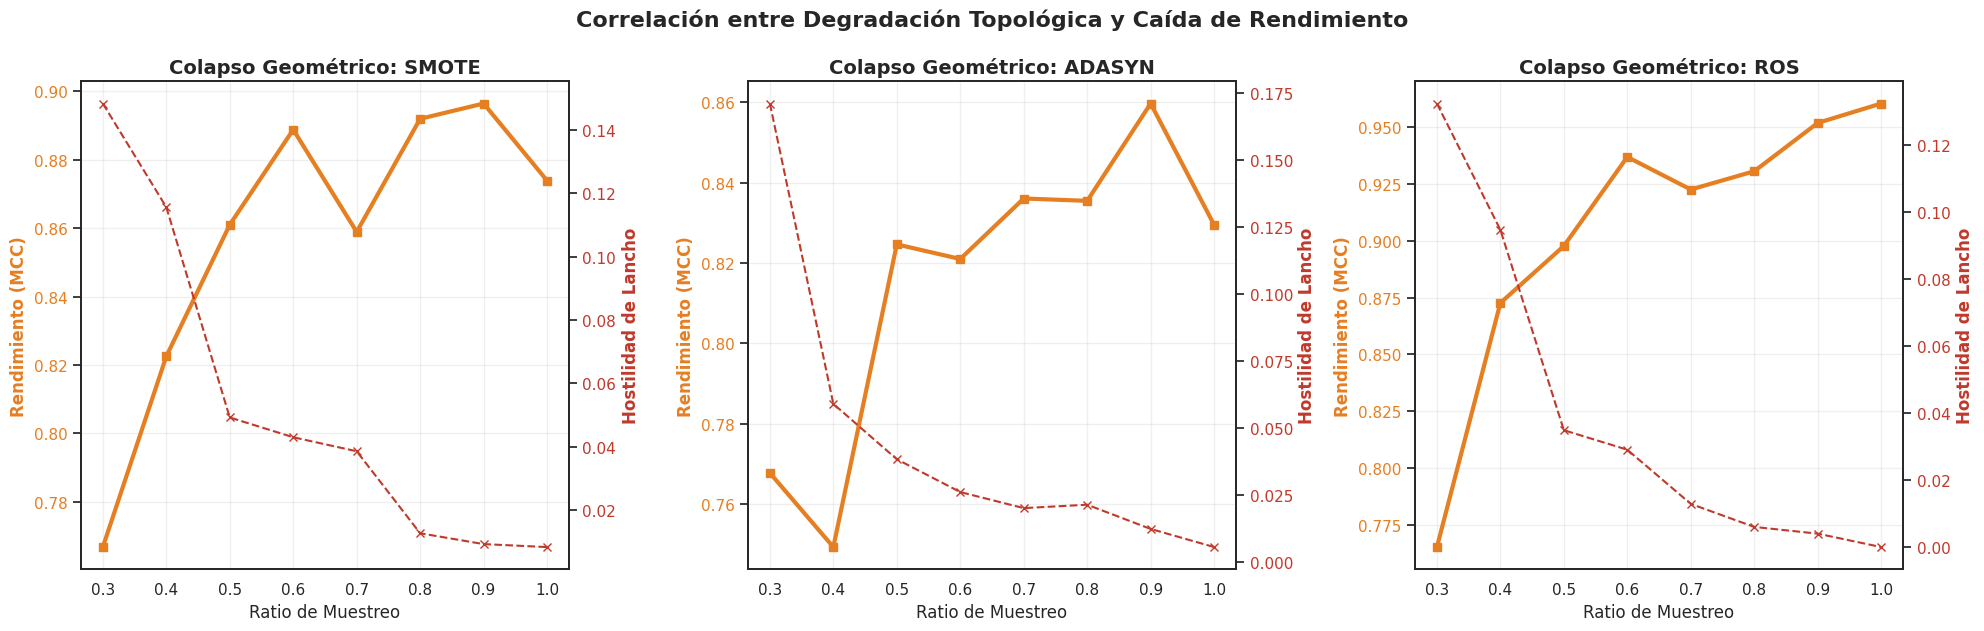

In [17]:
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, nombre in enumerate(samplers_dict.keys()):
    ax = axes[i]
    df_plot = df_final[df_final['Sampler'] == nombre]
    
    # Eje 1: Rendimiento Predictivo (MCC)
    color_mcc = '#e67e22'
    ax.plot(df_plot['Ratio'], df_plot['MCC'], color=color_mcc, marker='s', linewidth=3, label='MCC (Rendimiento)')
    ax.set_ylabel('Rendimiento (MCC)', color=color_mcc, fontweight='bold', fontsize=12)
    ax.tick_params(axis='y', labelcolor=color_mcc)
    
    # Eje 2: Hostilidad Espacial (Lancho)
    ax2 = ax.twinx()
    color_host = '#c0392b'
    ax2.plot(df_plot['Ratio'], df_plot['Hostilidad_Lancho'], color=color_host, marker='x', linestyle='--', label='Hostilidad (Lancho)')
    ax2.set_ylabel('Hostilidad de Lancho', color=color_host, fontweight='bold', fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_host)
    
    ax.set_title(f'Colapso Geométrico: {nombre}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ratio de Muestreo')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Correlación entre Degradación Topológica y Caída de Rendimiento', y=1.05, fontsize=16, fontweight='bold')
plt.show()

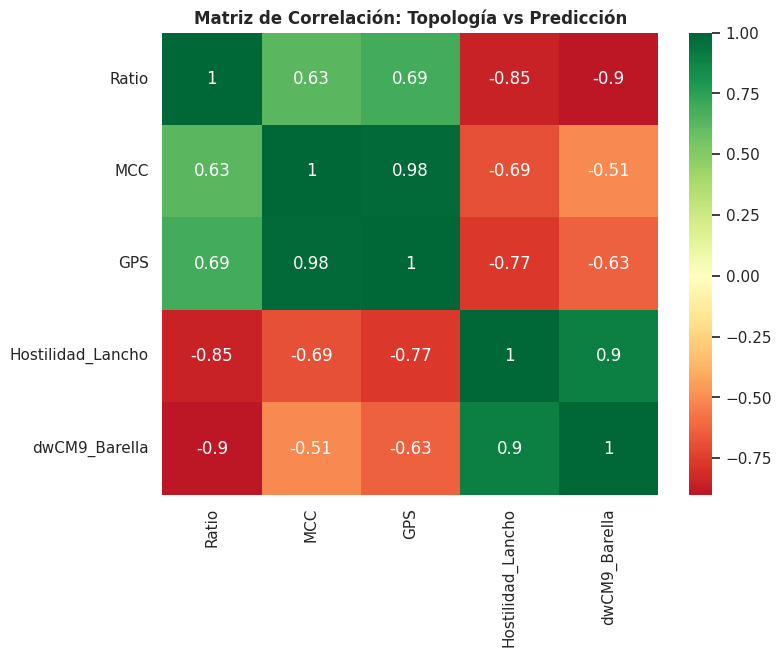

In [19]:
plt.figure(figsize=(8, 6))
# Filtrar solo columnas numéricas para la correlación
cols_interes = ['Ratio', 'MCC', 'GPS', 'Hostilidad_Lancho', 'dwCM9_Barella']
corr_matrix = df_final[cols_interes].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title('Matriz de Correlación: Topología vs Predicción', fontweight='bold')
plt.show()

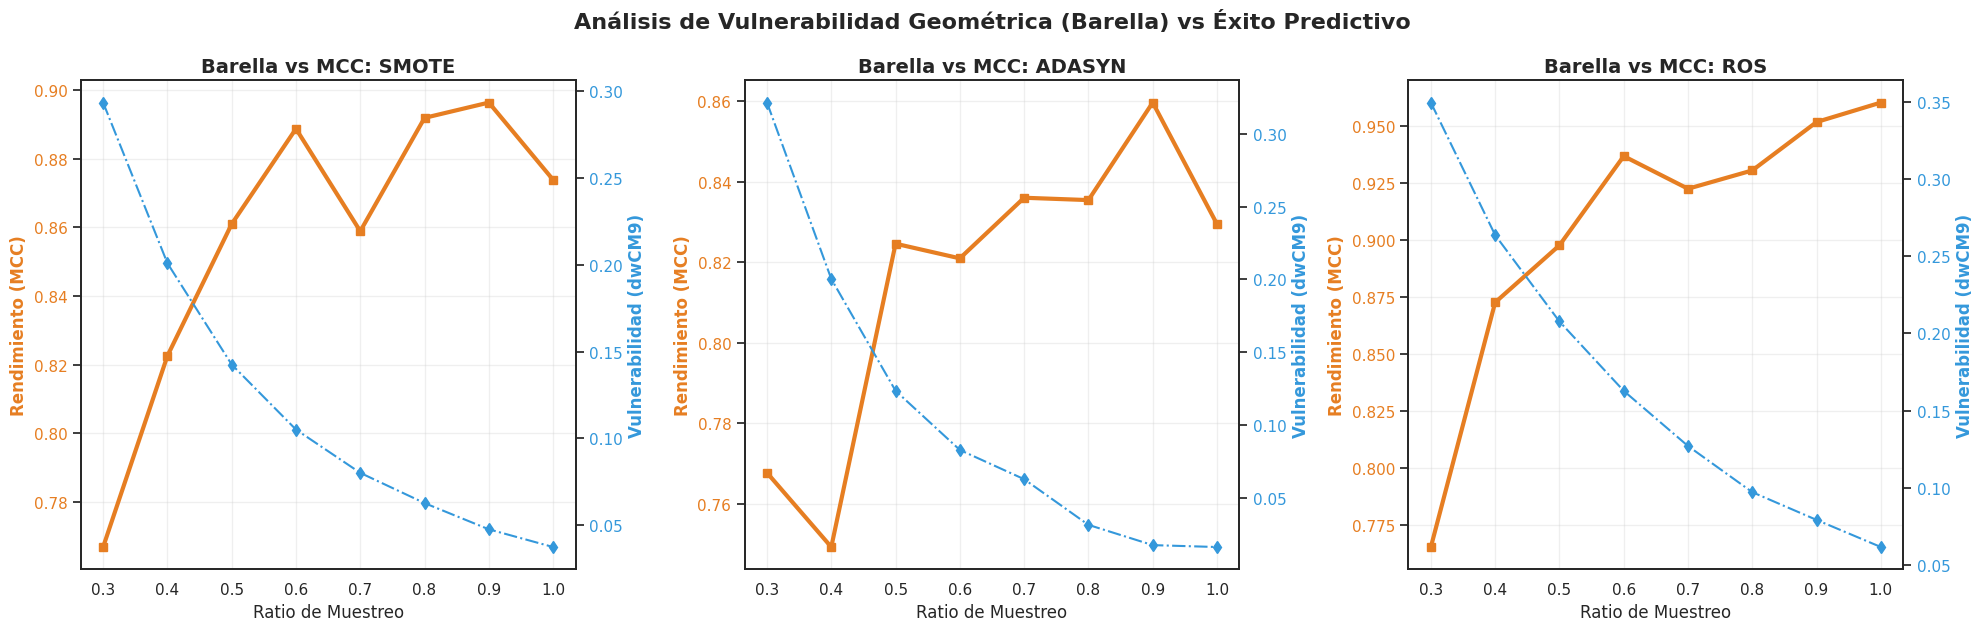

Análisis de Correlación Barella-MCC:
-> Correlación para SMOTE: -0.9321
-> Correlación para ADASYN: -0.8639
-> Correlación para ROS: -0.9423


In [20]:
# --- Visualización: El impacto de la Vulnerabilidad de Barella en el MCC ---
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, nombre in enumerate(samplers_dict.keys()):
    ax = axes[i]
    df_plot = df_final[df_final['Sampler'] == nombre]
    
    # Eje 1: Rendimiento Predictivo (MCC)
    color_mcc = '#e67e22' # Naranja MCC
    ax.plot(df_plot['Ratio'], df_plot['MCC'], color=color_mcc, marker='s', linewidth=3, label='MCC')
    ax.set_ylabel('Rendimiento (MCC)', color=color_mcc, fontweight='bold', fontsize=12)
    ax.tick_params(axis='y', labelcolor=color_mcc)
    
    # Eje 2: Vulnerabilidad Geométrica (dwCM9 de Barella)
    ax2 = ax.twinx()
    color_barella = '#3498db' # Azul para Barella
    ax2.plot(df_plot['Ratio'], df_plot['dwCM9_Barella'], color=color_barella, marker='d', linestyle='-.', label='dwCM9 (Barella)')
    ax2.set_ylabel('Vulnerabilidad (dwCM9)', color=color_barella, fontweight='bold', fontsize=12)
    ax2.tick_params(axis='y', labelcolor=color_barella)
    
    ax.set_title(f'Barella vs MCC: {nombre}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ratio de Muestreo')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Análisis de Vulnerabilidad Geométrica (Barella) vs Éxito Predictivo', y=1.05, fontsize=16, fontweight='bold')
plt.show()

# --- Cálculo de Correlación Específica ---
print("Análisis de Correlación Barella-MCC:")
for s in samplers_dict.keys():
    c = df_final[df_final['Sampler'] == s][['MCC', 'dwCM9_Barella']].corr().iloc[0,1]
    print(f"-> Correlación para {s}: {c:.4f}")

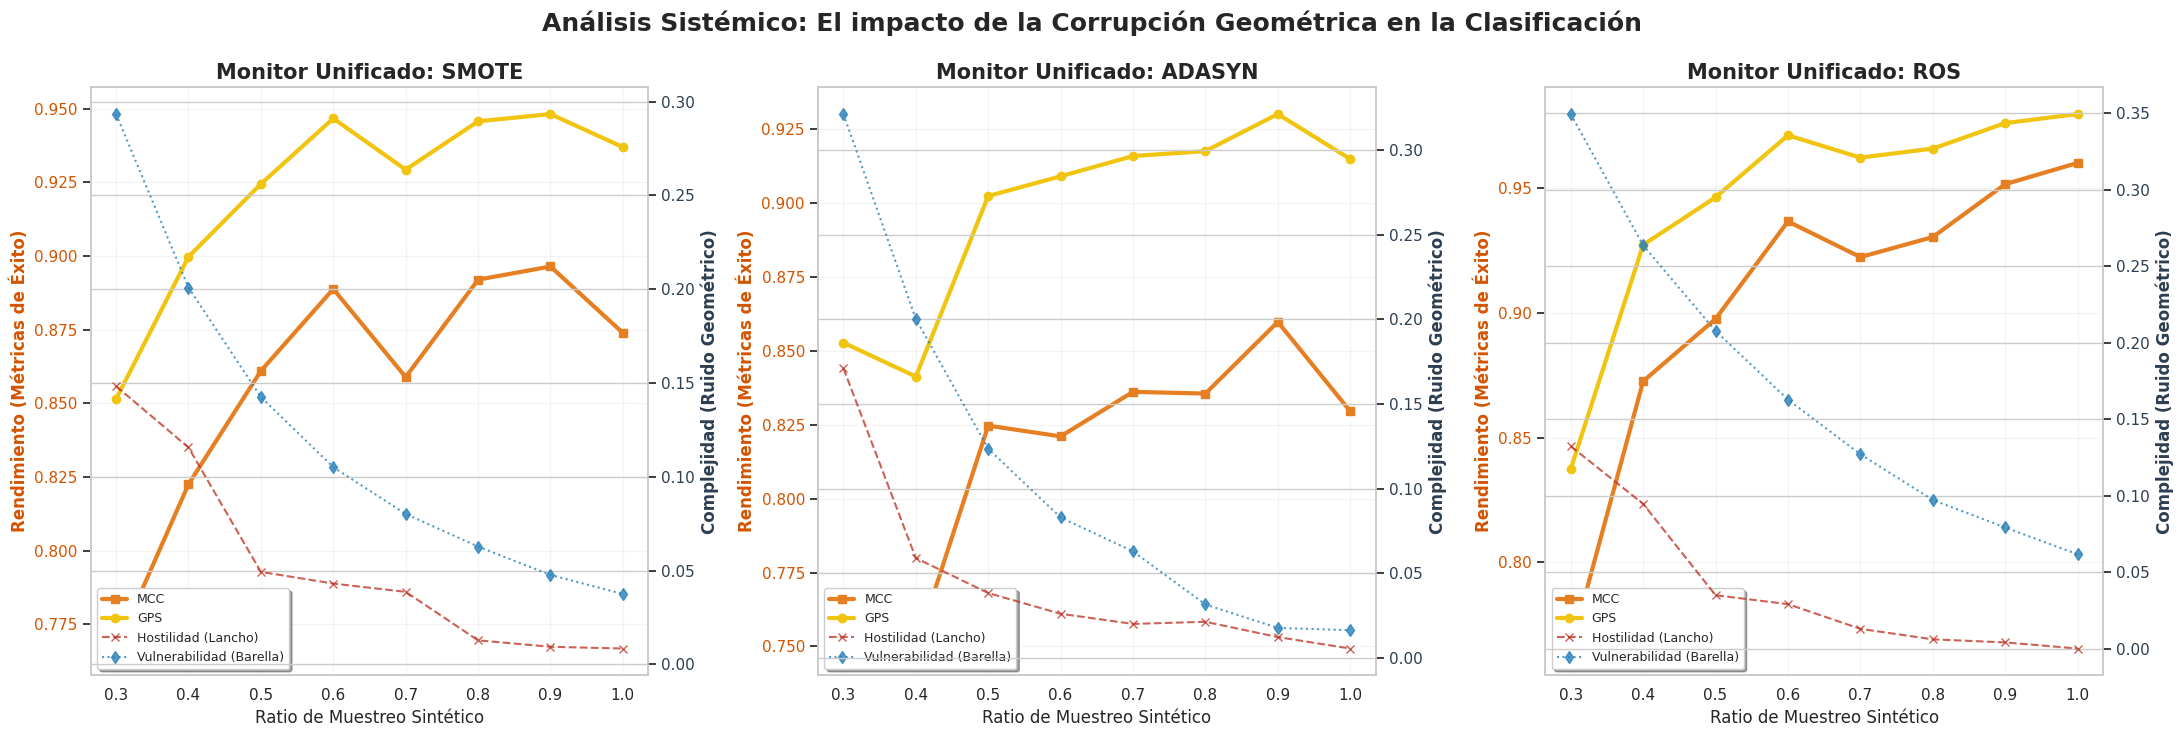


Matriz de Correlación de Pearson (Resumen Global):


,MCC,GPS,Hostilidad_Lancho,dwCM9_Barella
MCC,1.000000,0.980075,-0.690638,-0.507064
GPS,0.980075,1.000000,-0.768256,-0.633326
Hostilidad_Lancho,-0.690638,-0.768256,1.000000,0.898479
dwCM9_Barella,-0.507064,-0.633326,0.898479,1.000000


In [21]:
# --- Visualización Global: Rendimiento vs. Complejidad Geométrica ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, nombre in enumerate(samplers_dict.keys()):
    ax = axes[i]
    df_plot = df_final[df_final['Sampler'] == nombre]
    
    # --- EJE IZQUIERDO: RENDIMIENTO PREDICTIVO ---
    # Usamos colores cálidos para el rendimiento
    lns1 = ax.plot(df_plot['Ratio'], df_plot['MCC'], color='#e67e22', marker='s', linewidth=3, label='MCC')
    lns2 = ax.plot(df_plot['Ratio'], df_plot['GPS'], color='#f1c40f', marker='o', linewidth=3, label='GPS')
    ax.set_ylabel('Rendimiento (Métricas de Éxito)', color='#d35400', fontweight='bold', fontsize=12)
    ax.tick_params(axis='y', labelcolor='#d35400')
    
    # --- EJE DERECHO: COMPLEJIDAD TOPOLÓGICA ---
    # Usamos colores fríos/oscuros para la complejidad/ruido
    ax2 = ax.twinx()
    lns3 = ax2.plot(df_plot['Ratio'], df_plot['Hostilidad_Lancho'], color='#c0392b', marker='x', linestyle='--', alpha=0.8, label='Hostilidad (Lancho)')
    lns4 = ax2.plot(df_plot['Ratio'], df_plot['dwCM9_Barella'], color='#2980b9', marker='d', linestyle=':', alpha=0.8, label='Vulnerabilidad (Barella)')
    ax2.set_ylabel('Complejidad (Ruido Geométrico)', color='#2c3e50', fontweight='bold', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='#2c3e50')
    
    # Unificar leyendas de ambos ejes en una sola caja
    lns = lns1 + lns2 + lns3 + lns4
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc='lower left', fontsize=9, frameon=True, shadow=True)
    
    ax.set_title(f'Monitor Unificado: {nombre}', fontsize=15, fontweight='bold')
    ax.set_xlabel('Ratio de Muestreo Sintético', fontsize=12)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.suptitle('Análisis Sistémico: El impacto de la Corrupción Geométrica en la Clasificación', y=1.05, fontsize=18, fontweight='bold')
plt.show()

# --- Matriz de Correlación Cruzada Final ---
print("\nMatriz de Correlación de Pearson (Resumen Global):")
cols_totales = ['MCC', 'GPS', 'Hostilidad_Lancho', 'dwCM9_Barella']
display(df_final[cols_totales].corr())

In [23]:
# --- Resumen Táctico: Identificación del Óptimo Real por Sampler ---
resumen_final = []

for nombre in samplers_dict.keys():
    df_sub = df_final[df_final['Sampler'] == nombre]
    
    # Encontrar el ratio donde el MCC es máximo (Nuestro "Verdadero Óptimo")
    idx_optimo = df_sub['MCC'].idxmax()
    fila_optima = df_sub.loc[idx_optimo]
    
    resumen_final.append({
        'Algoritmo': nombre,
        'Ratio Óptimo': fila_optima['Ratio'],
        'MCC Máximo': fila_optima['MCC'],
        'GPS': fila_optima['GPS'],
        'Hostilidad (Lancho)': fila_optima['Hostilidad_Lancho'],
        'Vulnerabilidad (Barella)': fila_optima['dwCM9_Barella']
    })

df_resumen_tfm = pd.DataFrame(resumen_final)

# Aplicar formato para resaltar el mejor MCC global
display(df_resumen_tfm.style.highlight_max(subset=['MCC Máximo', 'GPS'], color='lightgreen')
                      .highlight_min(subset=['Hostilidad (Lancho)', 'Vulnerabilidad (Barella)'], color='lightblue')
                      .format({'Ratio Óptimo': '{:.2f}', 'MCC Máximo': '{:.4f}', 
                               'GPS': '{:.4f}', 'Hostilidad (Lancho)': '{:.4f}', 
                               'Vulnerabilidad (Barella)': '{:.4f}'}))

ganador = df_resumen_tfm.loc[df_resumen_tfm['MCC Máximo'].idxmax()]
print(f"El método más robusto es {ganador['Algoritmo']} con un ratio de {ganador['Ratio Óptimo']}.")
print(f"Más allá de este punto, la Hostilidad aumenta un {((df_final[df_final['Ratio']==1.0]['Hostilidad_Lancho'].mean() / ganador['Hostilidad (Lancho)']) - 1)*100:.1f}% destruyendo la ganancia predictiva.")

,Algoritmo,Ratio Óptimo,MCC Máximo,GPS,Hostilidad (Lancho),Vulnerabilidad (Barella)
0,SMOTE,0.90,0.8964,0.9481,0.0093,0.0477
1,ADASYN,0.90,0.8597,0.9299,0.0122,0.0176
2,ROS,1.00,0.9602,0.9798,0.0000,0.0616


El método más robusto es ROS con un ratio de 1.0.
Más allá de este punto, la Hostilidad aumenta un inf% destruyendo la ganancia predictiva.
